In [1]:
import os
import torch
from tqdm import tqdm
from tqdm import tqdm
import seaborn as sns
import cv2 as cv
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F
from scipy.ndimage import label, center_of_mass
from open_clip import create_model_from_pretrained, create_model_and_transforms, get_tokenizer 
from transformers import AutoModel, AutoProcessor
from PIL import Image, ImageDraw, ImageFont
from transformers.image_utils import load_image
import torch
import numpy as np
import torch.nn.functional as F
from collections import Counter
import spacy

from utils import default_argument_parser, Compute_IoU, extract_noun_phrase, gen_dir_mask, extract_dir_phrase, extract_rela_word, relation_boxes, extract_nouns, mask_to_bbox_mask, mask_iou_diversity, extract_noun_phrase_aug, generate_candidates

In [2]:
folder_dir = '/home/nsml/notebooks'
file_name = 'giraffe.jpeg'
file_path = os.path.join(folder_dir, file_name)


vision_model_type = "google/siglip2-base-patch16-384"
device = 'cuda:0'
pool_mode = 'full'
dim = 24

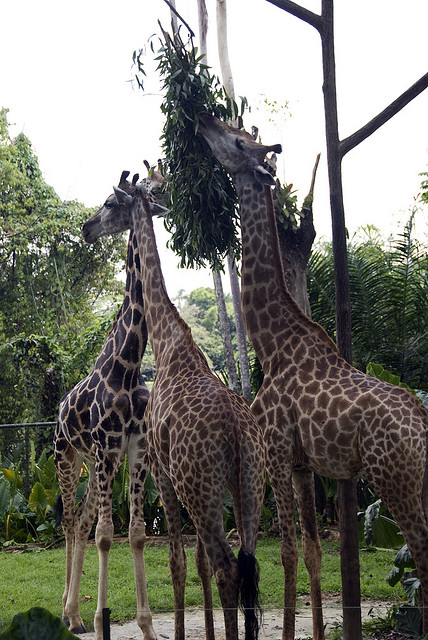

In [3]:
img = cv.imread(file_path)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img = Image.fromarray(img)
img.show()  

In [4]:
orig_text_lst = ["the giraffe in the middle"]
# orig_text_lst = ['a bush of plant behind middle woman', 'a bush of green plant on the left plant', "green plant behind a table visible behind a lady's head."] #["green plant"] # ["the giraffe in the middle"] #["green plant"] # behind a table visible behind a lady's head."] '

In [5]:
idx = 0

In [6]:
CACHE_DIR = "/mnt/tmp/"

model = AutoModel.from_pretrained(vision_model_type).to(device)
tokenizer = AutoProcessor.from_pretrained(vision_model_type).tokenizer
processor = AutoProcessor.from_pretrained(vision_model_type)

vision_model = model.vision_model
model

config.json:   0%|          | 0.00/276 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/34.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

SiglipModel(
  (text_model): SiglipTextTransformer(
    (embeddings): SiglipTextEmbeddings(
      (token_embedding): Embedding(256000, 768)
      (position_embedding): Embedding(64, 768)
    )
    (encoder): SiglipEncoder(
      (layers): ModuleList(
        (0-11): 12 x SiglipEncoderLayer(
          (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (self_attn): SiglipAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): SiglipMLP(
            (activation_fn): PytorchGELUTanh()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_

In [7]:
target_layers = ['vision_model.encoder.layers[0].layer_norm2',
                 'vision_model.encoder.layers[1].layer_norm2',
                 'vision_model.encoder.layers[2].layer_norm2',
                 'vision_model.encoder.layers[3].layer_norm2',
                 'vision_model.encoder.layers[4].layer_norm2',
                 'vision_model.encoder.layers[5].layer_norm2',
                 'vision_model.encoder.layers[6].layer_norm2',
                 'vision_model.encoder.layers[7].layer_norm2',
                 'vision_model.encoder.layers[8].layer_norm2',
                 'vision_model.encoder.layers[9].layer_norm2',
                 'vision_model.encoder.layers[10].layer_norm2',
                 'vision_model.encoder.layers[11].layer_norm2']

In [8]:
def get_activation(outputs, mode):
    '''
    mode: how to pool activations: one of avg, max
    for fc or ViT neurons does no pooling
    '''
    if mode=='avg':
        def hook(model, input, output):
            # print(output.shape)
            if len(output.shape)==4: #CNN layers
                outputs.append(output.mean(dim=[2,3]).detach())
            elif len(output.shape)==3: #ViT
                if output.shape[1] == 1:
                    outputs.append(output[:, 0].clone())
                elif output.shape[1] == 0:
                    outputs.append(output[0, :].clone())
            elif len(output.shape)==2: #FC layers
                outputs.append(output.detach())
    elif mode=='max':
        def hook(model, input, output):
            if len(output.shape)==4: #CNN layers
                outputs.append(output.amax(dim=[2,3]).detach())
            elif len(output.shape)==3: #ViT
                outputs.append(output[:, 0].clone())
            elif len(output.shape)==2: #FC layers
                outputs.append(output.detach())
    elif mode=='full':
        def hook(model, input, output):
            outputs.append(output.detach())
    return hook

In [9]:
all_features = {target_layer:[] for target_layer in target_layers}
    
hooks = {}
for target_layer in tqdm(target_layers):
    command = "model.{}.register_forward_hook(get_activation(all_features[target_layer], pool_mode))".format(target_layer)
    hooks[target_layer] = eval(command)

100%|██████████| 12/12 [00:00<00:00, 10056.27it/s]


In [23]:
local_candidates = ['giraffe']
r = 0.6

In [24]:
inputs = processor(images=[load_image(img)], return_tensors="pt").to(device)
local_text = tokenizer(local_candidates, return_tensors="pt", padding="max_length", max_length=64).to(device)
global_text = tokenizer([orig_text_lst[idx]], return_tensors="pt", padding="max_length", max_length=64).to(device)

with torch.no_grad():
    image_features = model.get_image_features(**inputs)    
    local_text_features = model.get_text_features(**local_text)
    global_text_features = model.get_text_features(**global_text)
    hybrid_text_features = r * global_text_features + (1-r) * local_text_features 
    print(image_features.shape, hybrid_text_features.shape)

torch.Size([1, 768]) torch.Size([1, 768])


In [25]:
image_features /= image_features.norm(dim=-1, keepdim=True)
hybrid_text_features /= hybrid_text_features.norm(dim=-1, keepdim=True)
sim_matrix = (image_features @ hybrid_text_features.T)
sim_matrix

tensor([[0.1330]], device='cuda:0')

In [26]:
best_idx = sim_matrix[0].argmax(dim=-1).item()
local_candidates = [local_candidates[best_idx]]
local_candidates

['giraffe']

In [27]:
for i,layer_num in enumerate(range(12)): 
    inter_features = all_features[f'vision_model.encoder.layers[{layer_num}].layer_norm2'][0]
    inter_features = vision_model.post_layernorm(-inter_features)
    # inter_features = vision_model.head(inter_features)
    new_features_temp = inter_features.unsqueeze(0)

    new_features_temp = inter_features
    if i == 0:
        new_features = new_features_temp
    else:
        new_features = torch.cat((new_features, new_features_temp), 0)
    print(new_features.shape)
    print()

torch.Size([1, 576, 768])

torch.Size([2, 576, 768])

torch.Size([3, 576, 768])

torch.Size([4, 576, 768])

torch.Size([5, 576, 768])

torch.Size([6, 576, 768])

torch.Size([7, 576, 768])

torch.Size([8, 576, 768])

torch.Size([9, 576, 768])

torch.Size([10, 576, 768])

torch.Size([11, 576, 768])

torch.Size([12, 576, 768])



In [28]:
inputs = processor(images=[load_image(img)], return_tensors="pt").to(device)
local_text = tokenizer(local_candidates, return_tensors="pt", padding="max_length", max_length=64).to(device)
global_text = tokenizer([orig_text_lst[idx]], return_tensors="pt", padding="max_length", max_length=64).to(device)

with torch.no_grad():
    image_features = model.get_image_features(**inputs)    
    local_text_features = model.get_text_features(**local_text)
    global_text_features = model.get_text_features(**global_text)
    hybrid_text_features = r * global_text_features + (1-r) * local_text_features 
    print(image_features.shape, hybrid_text_features.shape)

torch.Size([1, 768]) torch.Size([1, 768])


In [29]:
new_features /= new_features.norm(dim=-1, keepdim=True)
hybrid_text_features /= hybrid_text_features.norm(dim=-1, keepdim=True)
sim_matrix = (new_features @ hybrid_text_features.T)
sim_matrix.shape

torch.Size([12, 576, 1])

In [30]:
sim_lst1 = []
sim_lst2 = []
for i in range(sim_matrix.shape[-1]):
    print('Word: ', local_candidates[i], '| Mean: ', sim_matrix[:, :, i].mean(1).mean(0).item(), '| Max: ', sim_matrix[:, :, i].max(1)[0].mean(0).item())
    print()
    sim_lst1.append(sim_matrix[:, :, i].mean(1).mean(0).item())
    sim_lst2.append(sim_matrix[:, :, i].max(1)[0].mean(0).item())

Word:  giraffe | Mean:  -0.008440916426479816 | Max:  0.06257136911153793



In [31]:
sim_lst1 = []
sim_lst2 = []

for i in range(sim_matrix.shape[0]):
    print('Layer: ', i, '| Mean: ', sim_matrix[i, :, idx].mean(0).item(), '| Max: ', sim_matrix[i, :, idx].max(0)[0].item())
    print()
    sim_lst1.append(sim_matrix[i, :, idx].mean(0).item())
    sim_lst2.append(sim_matrix[i, :, idx].max(0)[0].item())

Layer:  0 | Mean:  -0.004016317892819643 | Max:  0.07303013652563095

Layer:  1 | Mean:  -0.020267507061362267 | Max:  0.05440839007496834

Layer:  2 | Mean:  -0.013534058816730976 | Max:  0.05100904777646065

Layer:  3 | Mean:  -0.0038617087993770838 | Max:  0.051779523491859436

Layer:  4 | Mean:  -0.014131461270153522 | Max:  0.07372035831212997

Layer:  5 | Mean:  -0.028722770512104034 | Max:  0.025821253657341003

Layer:  6 | Mean:  -0.02780652418732643 | Max:  0.04889177531003952

Layer:  7 | Mean:  -0.013816720806062222 | Max:  0.059777624905109406

Layer:  8 | Mean:  0.022067423909902573 | Max:  0.09814572334289551

Layer:  9 | Mean:  0.03361023589968681 | Max:  0.12043631076812744

Layer:  10 | Mean:  0.00022340223949868232 | Max:  0.0643213763833046

Layer:  11 | Mean:  -0.031034983694553375 | Max:  0.029514875262975693



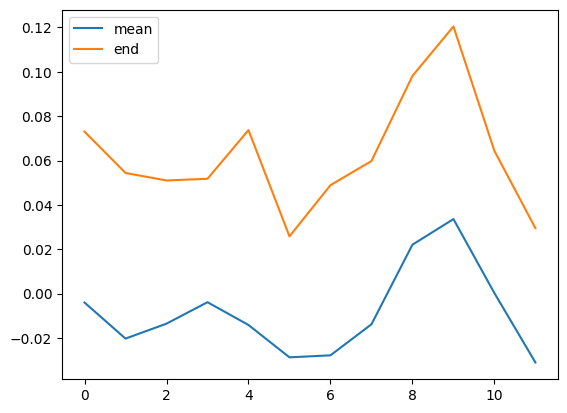

In [32]:
plt.plot(sim_lst1, label='mean')
plt.plot(sim_lst2, label='end')
plt.legend()
plt.show()

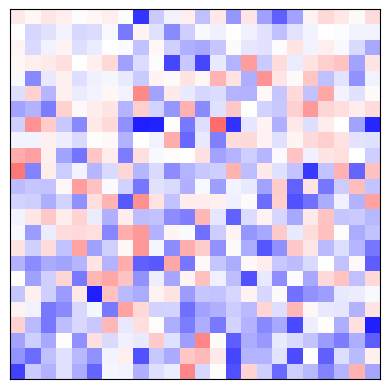

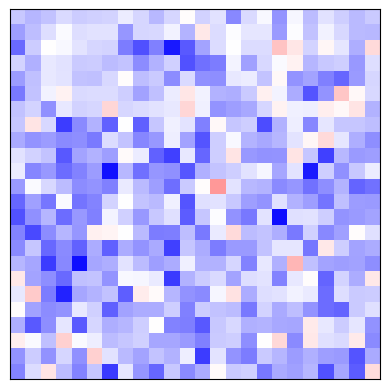

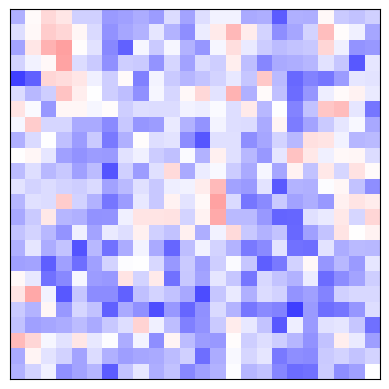

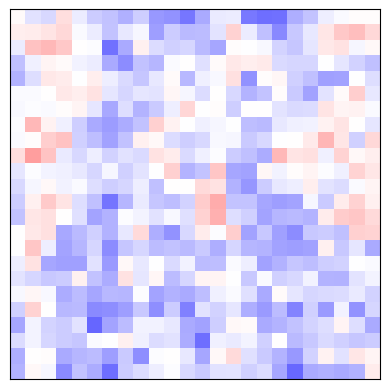

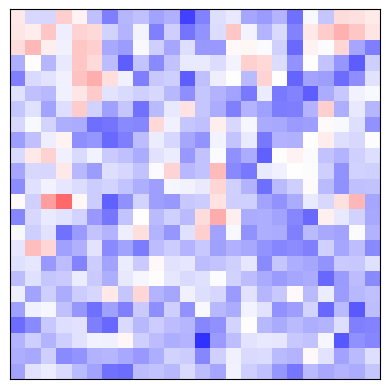

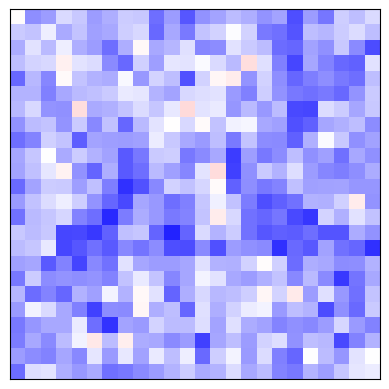

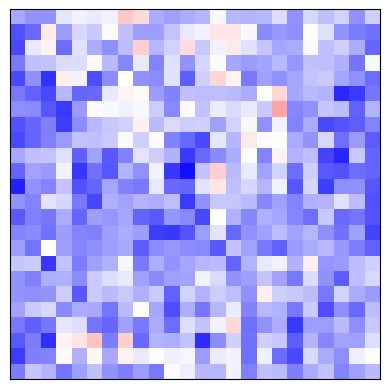

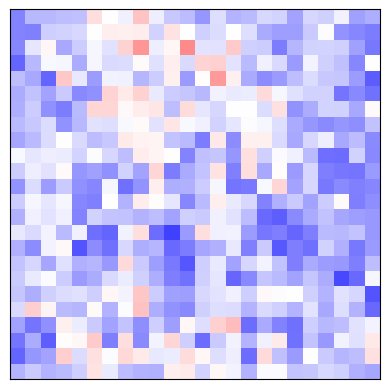

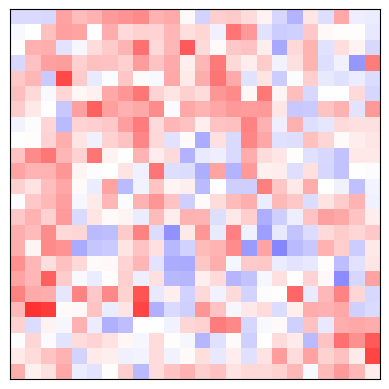

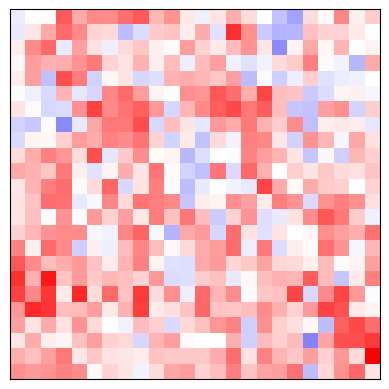

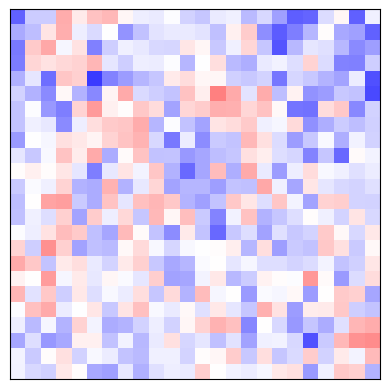

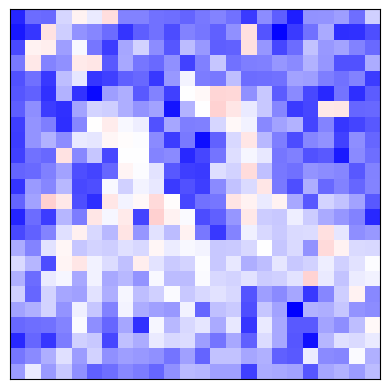

In [36]:
sns.set_style({'font.family':'serif', 'font.serif':['Times New Roman']})

cmap = plt.get_cmap('bwr')

min_v = sim_matrix[:, :, :].min().item()
max_v = sim_matrix[:, :, :].max().item()

mean_sim = sim_matrix[:, :, :].mean(0).unsqueeze(0)

clim_min = min_v
clim_max = max_v

for j in range(sim_matrix.shape[0]):
    plt.imshow(sim_matrix[j, :, idx].reshape(dim, dim).detach().cpu().numpy(), cmap=cmap)
    plt.xticks([])
    plt.yticks([])
    # plt.xticks(ticks=range(dim), labels=range(1, dim+1))
    # plt.yticks(ticks=range(dim), labels=range(1, dim+1))
    # plt.colorbar(shrink=0.8, aspect=20)
    plt.clim(clim_min, clim_max)
   
    # plt.title(f'Layer: {j}', fontsize=20)
    plt.show()

    low_percentile=10
    high_percentile=90

    # Flatten the array
    flattened = sim_matrix[j, :, idx].detach().cpu().numpy().flatten()
    
    # Compute percentiles
    low_threshold = np.percentile(flattened, low_percentile)
    high_threshold = np.percentile(flattened, high_percentile)
    
    # Extract low and high regions based on percentiles
    low_region = flattened[flattened <= low_threshold]
    high_region = flattened[flattened >= high_threshold]
    
    # Calculate mean values for low and high regions
    mean_low = np.mean(low_region).item()
    mean_high = np.mean(high_region).item()
    cluster_score = round(mean_high - mean_low, 2)
    
    # plt.figure(figsize=(5, 3))
    # plt.hist(sim_matrix[j, :, idx].detach().cpu().numpy(), color='#7adde3')
    # plt.axvline(mean_low, color='gray', linewidth=0.75)
    # plt.axvline(mean_high, color='gray', linewidth=0.75)
    # plt.xlim(min_v, max_v)
    # plt.tight_layout()
    # plt.title(f'{local_candidates[idx]} (Cluster score: {cluster_score})', fontsize=15) 
    # plt.show()


# plt.imshow(sim_matrix[11:, :, idx].mean(0).reshape(dim, dim).detach().cpu().numpy(), cmap=cmap)
# plt.xticks([])
# plt.yticks([])
# plt.xticks(ticks=range(dim), labels=range(1, dim+1))
# plt.yticks(ticks=range(dim), labels=range(1, dim+1))
# plt.colorbar(shrink=0.8, aspect=20)
# plt.clim(clim_min, clim_max)

# plt.title(f'{orig_text_lst[idx]} (Mean)', fontsize=15)
# plt.show()